In [ ]:
# Celda 1: Importaciones y configuración
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Configuración de visualizaciones
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Definir rutas del proyecto
DATA_RAW = "../data/raw"
DATA_PROCESSED = "../data/processed"
OUTPUTS_FIG = "../outputs/figures"

os.makedirs(DATA_RAW, exist_ok=True)
os.makedirs(DATA_PROCESSED, exist_ok=True)
os.makedirs(OUTPUTS_FIG, exist_ok=True)

print("✅ Configuración lista")

In [ ]:
# Celda 2: Inspeccionar los archivos del dataset de K-pop
ruta_kpop = "../data/raw/kpop_spotify/"

archivos = [
    "273_kArtists.csv",
    "album_to_track_df.csv",
    "artist_appears_on_df.csv",
    "compilation_track.csv",
    "single_album_track_data.csv"
]

for archivo in archivos:
    print("=" * 70)
    print(f"📄 {archivo}")
    print("=" * 70)
    df_temp = pd.read_csv(os.path.join(ruta_kpop, archivo))
    print(f"Dimensiones: {df_temp.shape[0]:,} filas × {df_temp.shape[1]} columnas")
    print(f"Columnas: {df_temp.columns.tolist()}")
    print("\nPrimeras 2 filas:")
    print(df_temp.head(2))
    print("\n")

In [ ]:
# Celda 3: Inspeccionar en detalle el archivo principal
import pandas as pd

ruta_album_track = "../data/raw/kpop_spotify/album_to_track_df.csv"
df = pd.read_csv(ruta_album_track)

# Ver todas las columnas con su tipo de dato
print("📋 Todas las columnas con su tipo de dato:")
print(df.dtypes)
print(f"\n📊 Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n🔢 Valores únicos por columna:")
print(df.nunique())

In [ ]:
# Celda 4: ¿Está BTS en el dataset?
print(f"Total de artistas únicos: {df['Artist'].nunique()}")
print(f"Total de tracks: {len(df)}")

# Buscar BTS
bts_df = df[df['Artist'].str.contains('BTS', case=False, na=False)]
print(f"\n🎯 Tracks de BTS encontrados: {len(bts_df)}")
print(f"Álbumes únicos de BTS: {bts_df['Album_Name'].nunique()}")

# Ver los álbumes de BTS
print("\n📀 Álbumes de BTS:")
for album in bts_df['Album_Name'].unique():
    print(f"  - {album}")

In [ ]:
# Celda 5: Diagnóstico de duplicados y nulos (SOLO OBSERVACIÓN)

print("=" * 70)
print("📊 DIAGNÓSTICO DE DUPLICADOS")
print("=" * 70)

# 1. Duplicados de filas enteras
duplicados_completos = df.duplicated().sum()
print(f"\n1️⃣ Filas duplicadas (idénticas en todas las columnas): {duplicados_completos}")

# 2. Duplicados por Track_Id
duplicados_track_id = df.duplicated(subset=['Track_Id']).sum()
print(f"\n2️⃣ Filas con Track_Id repetido: {duplicados_track_id}")

# 3. Ver ejemplos de los Track_Id duplicados
tracks_repetidos = df[df.duplicated(subset=['Track_Id'], keep=False)].sort_values('Track_Id')
print(f"\n3️⃣ Total de filas involucradas en Track_Id repetidos: {len(tracks_repetidos)}")
print(f"   Total de Track_Id únicos que se repiten: {tracks_repetidos['Track_Id'].nunique()}")

# Mostrar un ejemplo
if len(tracks_repetidos) > 0:
    primer_track_dup = tracks_repetidos['Track_Id'].iloc[0]
    print(f"\n   📌 Ejemplo de un Track_Id repetido ({primer_track_dup}):")
    print(df[df['Track_Id'] == primer_track_dup][['Artist', 'Album_Name', 'Track_Title', 'Track_Id']])

print("\n" + "=" * 70)
print("🔍 DIAGNÓSTICO DE VALORES NULOS")
print("=" * 70)

nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)

resumen_nulos = pd.DataFrame({
    'Nulos': nulos,
    'Porcentaje (%)': nulos_pct
}).sort_values('Nulos', ascending=False)

print(resumen_nulos)
print(f"\n📌 Total de celdas con nulos: {df.isnull().sum().sum():,}")
print(f"📌 Porcentaje total de celdas con nulos: {(df.isnull().sum().sum() / (len(df) * len(df.columns)) * 100):.4f}%")

In [ ]:
# Celda 6: Limpieza del dataset (Punto 3 del TP)

print("=" * 70)
print("🧹 LIMPIEZA DEL DATASET")
print("=" * 70)

# Guardamos las dimensiones originales para comparar
filas_originales = len(df)
columnas_originales = len(df.columns)
print(f"\n📊 ANTES: {filas_originales:,} filas × {columnas_originales} columnas")

# ---------------------------------------------------------------
# PASO 1: Eliminar la columna 'Unnamed: 0' (es solo el índice del CSV)
# ---------------------------------------------------------------
df = df.drop(columns=['Unnamed: 0'])
print(f"\n1️⃣ Columna 'Unnamed: 0' eliminada. Columnas restantes: {len(df.columns)}")

# ---------------------------------------------------------------
# PASO 2: Eliminar filas con valores nulos
# ---------------------------------------------------------------
# Son solo 8 filas (0.05%) sin features de audio. No aportan al análisis.
df = df.dropna()
print(f"2️⃣ Filas con nulos eliminadas. Filas restantes: {len(df):,}")

# ---------------------------------------------------------------
# PASO 3: Convertir 'duration_ms' a minutos
# ---------------------------------------------------------------
# Se crea una columna nueva y se elimina la original en ms
df['duration_min'] = (df['duration_ms'] / 60000).round(2)
df = df.drop(columns=['duration_ms'])
print(f"3️⃣ 'duration_ms' convertida a 'duration_min' (minutos)")

# ---------------------------------------------------------------
# PASO 4: Resetear el índice
# ---------------------------------------------------------------
df = df.reset_index(drop=True)
print(f"4️⃣ Índice reseteado")

# ---------------------------------------------------------------
# RESUMEN FINAL
# ---------------------------------------------------------------
print("\n" + "=" * 70)
print(f"✅ DESPUÉS: {len(df):,} filas × {len(df.columns)} columnas")
print(f"   Filas eliminadas: {filas_originales - len(df)} ({(filas_originales - len(df)) / filas_originales * 100:.4f}%)")
print("=" * 70)

# Verificar que no queden nulos
nulos_restantes = df.isnull().sum().sum()
print(f"\n🔍 Nulos restantes: {nulos_restantes}")

# Ver las columnas finales
print(f"\n📋 Columnas finales ({len(df.columns)}):")
for col in df.columns:
    print(f"   - {col}")

# Vista previa del dataset limpio
print("\n👀 Primeras 3 filas del dataset limpio:")
df.head(3)

In [ ]:
# Celda 7: Guardar el dataset limpio en data/processed/
ruta_salida = "../data/processed/kpop_spotify_clean.csv"
df.to_csv(ruta_salida, index=False)
print(f"✅ Dataset limpio guardado en: {ruta_salida}")
print(f"📊 Dimensiones guardadas: {df.shape}")

# Verificar que el archivo se guardó
import os
tamaño_mb = os.path.getsize(ruta_salida) / (1024 * 1024)
print(f"📁 Tamaño del archivo: {tamaño_mb:.2f} MB")

In [ ]:
# Celda 8: Comparar danceability entre BTS y el resto de artistas

# Separar BTS del resto
df_bts = df[df['Artist'] == 'BTS']
df_otros = df[df['Artist'] != 'BTS']

print("=" * 70)
print("💃 ANÁLISIS DE DANCEABILITY: BTS vs OTROS ARTISTAS")
print("=" * 70)

# Estadísticas descriptivas
print(f"\n🎤 BTS (n = {len(df_bts)} tracks):")
print(f"   Media:     {df_bts['danceability'].mean():.4f}")
print(f"   Mediana:   {df_bts['danceability'].median():.4f}")
print(f"   Desv. std: {df_bts['danceability'].std():.4f}")
print(f"   Mínimo:    {df_bts['danceability'].min():.4f}")
print(f"   Máximo:    {df_bts['danceability'].max():.4f}")

print(f"\n🌍 Otros artistas (n = {len(df_otros)} tracks):")
print(f"   Media:     {df_otros['danceability'].mean():.4f}")
print(f"   Mediana:   {df_otros['danceability'].median():.4f}")
print(f"   Desv. std: {df_otros['danceability'].std():.4f}")
print(f"   Mínimo:    {df_otros['danceability'].min():.4f}")
print(f"   Máximo:    {df_otros['danceability'].max():.4f}")

# Diferencia de medias
diferencia = df_bts['danceability'].mean() - df_otros['danceability'].mean()
print(f"\n📊 Diferencia de medias (BTS - Otros): {diferencia:+.4f}")

# Visualización: boxplot comparativo
fig, ax = plt.subplots(figsize=(8, 5))
datos_plot = [df_bts['danceability'].values, df_otros['danceability'].values]
bp = ax.boxplot(datos_plot, tick_labels=['BTS', 'Otros artistas'], patch_artist=True)

# Colores
bp['boxes'][0].set_facecolor('#A78BFA')  # Violeta para BTS
bp['boxes'][1].set_facecolor('#93C5FD')  # Azul claro para otros

ax.set_title('Comparación de Danceability: BTS vs Otros Artistas', fontsize=14, fontweight='bold')
ax.set_ylabel('Danceability (0 a 1)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../outputs/figures/01_danceability_bts_vs_otros.png', dpi=100, bbox_inches='tight')
plt.show()

print("\n✅ Gráfico guardado en: outputs/figures/01_danceability_bts_vs_otros.png")

📊 TABLA COMPARATIVA: BTS vs OTROS ARTISTAS
         Métrica  BTS_Media  BTS_Mediana  BTS_Desv  Otros_Media  Otros_Mediana  Otros_Desv  Dif_Medias  BTS_menos_disperso
    danceability     0.6089       0.6060    0.1147       0.6064         0.6260      0.1562      0.0025                True
          energy     0.7764       0.8220    0.1612       0.7091         0.7530      0.2083      0.0673                True
         valence     0.5381       0.5440    0.2033       0.4968         0.4960      0.2378      0.0414                True
           tempo   120.8392     119.9470   27.7826     119.8390       120.0190     27.7882      1.0002                True
        loudness    -4.9542      -4.5180    2.7503      -6.0206        -5.3550      3.2015      1.0665                True
    acousticness     0.1372       0.0405    0.2007       0.2549         0.1450      0.2702     -0.1177                True
instrumentalness     0.0142       0.0000    0.0957       0.0515         0.0000      0.1921     -

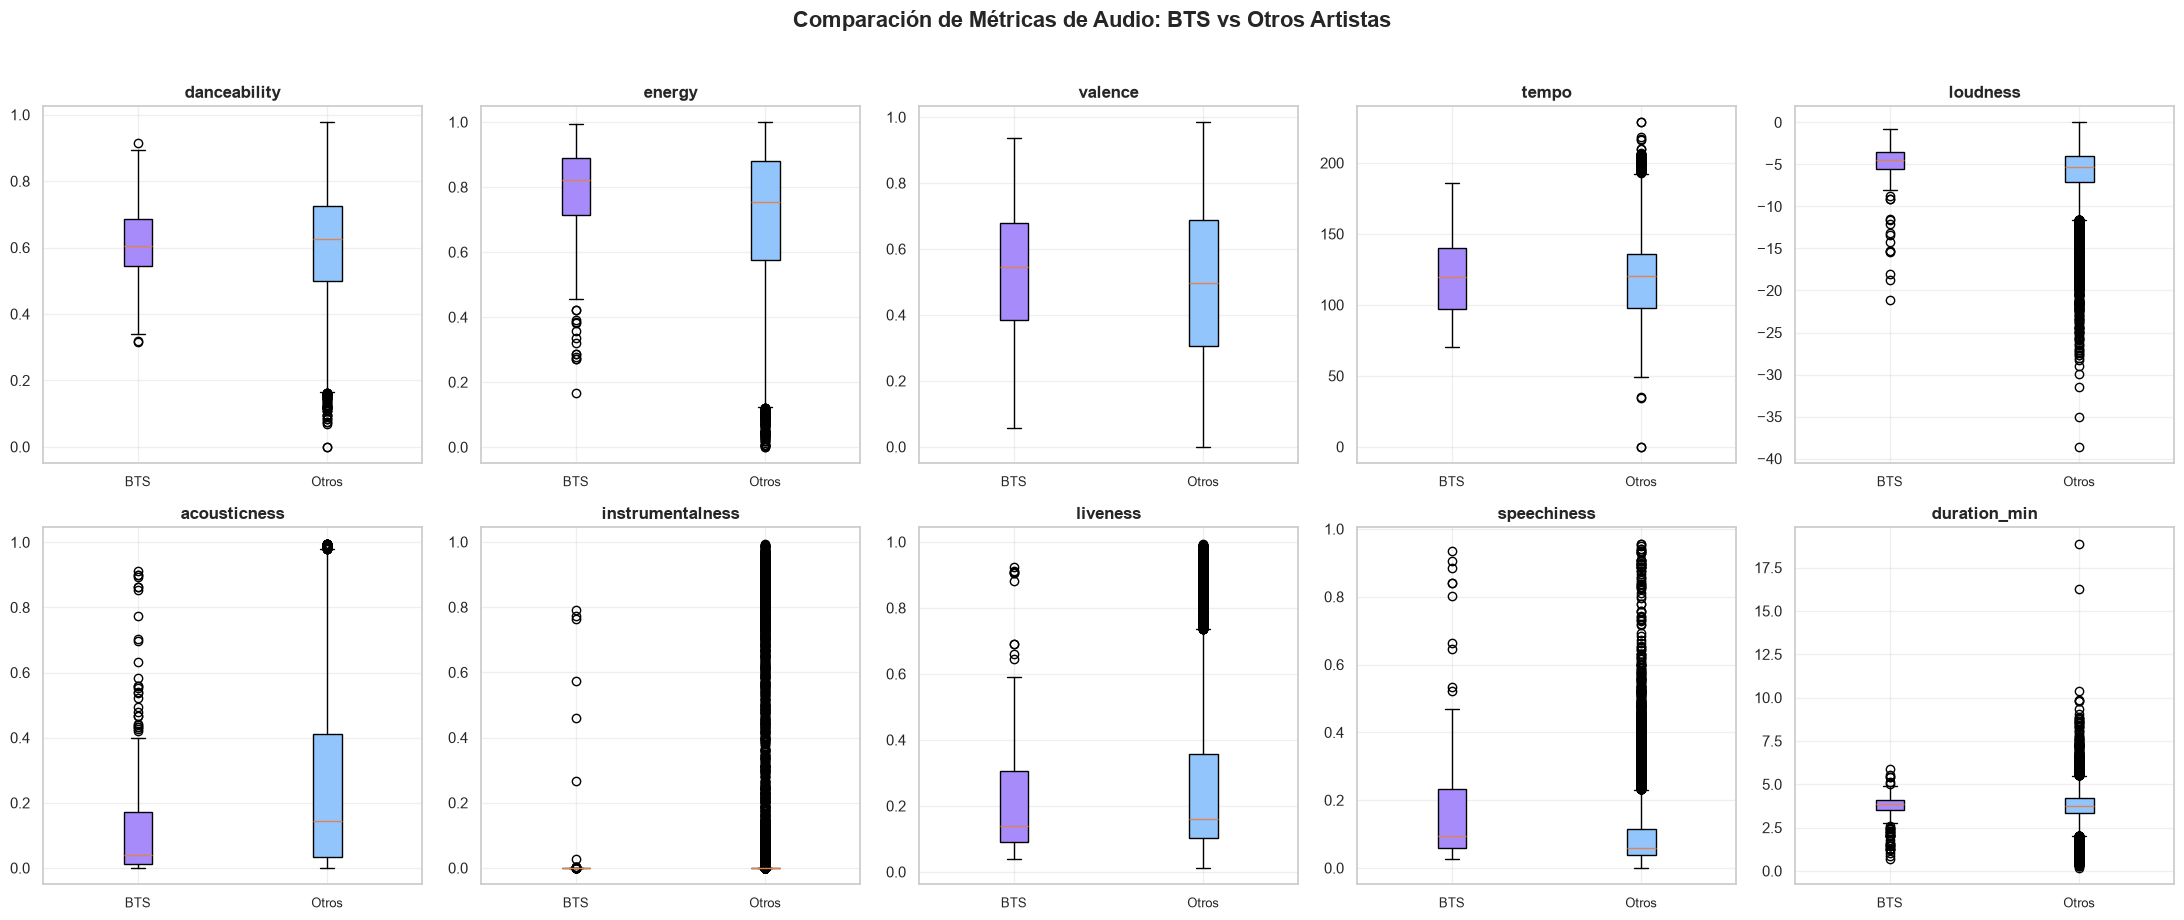

✅ Gráfico guardado en: outputs/figures/02_metricas_comparativas.png


In [11]:
# Celda 9: Análisis comparativo de TODAS las métricas de audio

# Métricas a analizar (todas las numéricas excepto los IDs y los categóricos binarios)
metricas = [
    'danceability', 'energy', 'valence', 'tempo', 'loudness',
    'acousticness', 'instrumentalness', 'liveness', 'speechiness',
    'duration_min'
]

# Separar BTS del resto
df_bts = df[df['Artist'] == 'BTS']
df_otros = df[df['Artist'] != 'BTS']

# Construir tabla comparativa
resumen = []
for metrica in metricas:
    resumen.append({
        'Métrica': metrica,
        'BTS_Media': round(df_bts[metrica].mean(), 4),
        'BTS_Mediana': round(df_bts[metrica].median(), 4),
        'BTS_Desv': round(df_bts[metrica].std(), 4),
        'Otros_Media': round(df_otros[metrica].mean(), 4),
        'Otros_Mediana': round(df_otros[metrica].median(), 4),
        'Otros_Desv': round(df_otros[metrica].std(), 4),
        'Dif_Medias': round(df_bts[metrica].mean() - df_otros[metrica].mean(), 4),
        'BTS_menos_disperso': df_bts[metrica].std() < df_otros[metrica].std()
    })

tabla_comparativa = pd.DataFrame(resumen)
print("=" * 90)
print("📊 TABLA COMPARATIVA: BTS vs OTROS ARTISTAS")
print("=" * 90)
print(tabla_comparativa.to_string(index=False))

# Guardar la tabla
tabla_comparativa.to_csv('../outputs/reports/comparativa_metricas.csv', index=False)
print("\n✅ Tabla guardada en: outputs/reports/comparativa_metricas.csv")

# ---------------------------------------------------------------
# VISUALIZACIÓN: Panel con boxplots para cada métrica
# ---------------------------------------------------------------
fig, axes = plt.subplots(2, 5, figsize=(22, 9))
axes = axes.flatten()

for i, metrica in enumerate(metricas):
    datos = [df_bts[metrica].values, df_otros[metrica].values]
    bp = axes[i].boxplot(datos, tick_labels=['BTS', 'Otros'], patch_artist=True)
    bp['boxes'][0].set_facecolor('#A78BFA')  # Violeta para BTS
    bp['boxes'][1].set_facecolor('#93C5FD')  # Azul para otros
    axes[i].set_title(metrica, fontweight='bold')
    axes[i].grid(True, alpha=0.3)
    axes[i].tick_params(axis='x', labelsize=9)

plt.suptitle('Comparación de Métricas de Audio: BTS vs Otros Artistas', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/02_metricas_comparativas.png', dpi=100, bbox_inches='tight')
plt.show()

print("✅ Gráfico guardado en: outputs/figures/02_metricas_comparativas.png")